- выполнила: Ахматова Ульяна, ИТХ-2-2021
- используемый датасет: Hearts Desease (https://archive.ics.uci.edu/dataset/45/heart+disease)

#Credit Card Fraud Detection Using Autoencoder

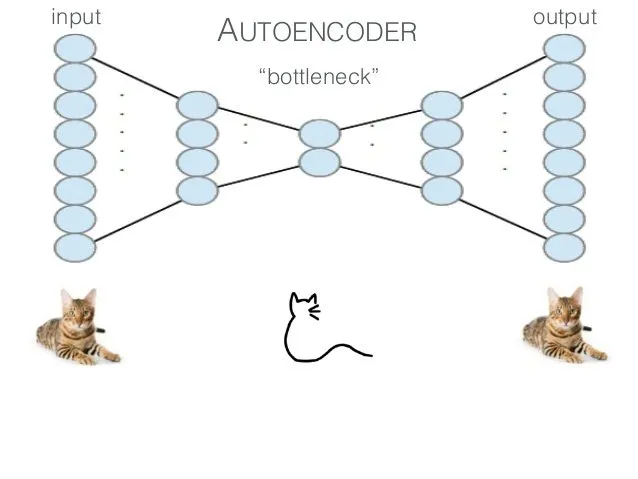

##Declare required dependencies

In [1]:
pip install ucimlrepo

In [2]:
import pandas as pd
import numpy as np
import pickle

from torch.autograd import Variable
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


import torch.utils.data as data_utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

from sklearn.metrics import (confusion_matrix, precision_recall_curve, auc,
                             roc_curve, recall_score, classification_report, f1_score,
                             precision_recall_fscore_support)

from ucimlrepo import fetch_ucirepo

In [31]:
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42
LABELS = ['0', '1']

## Data ingestion

In [161]:
heart_disease = fetch_ucirepo(id=45)

dx = heart_disease.data.features
dy = heart_disease.data.targets

df = pd.concat([dx, dy], axis=1)

- cp -
- trestbps - артериальное давление в состоянии покоя при поступлении в больницу
- chol - холестерин
- fbs - уровень сахара в крови
- restecg -
- thalach - максимальная частота сердечных сокращений
- exang - стенокардия, вызванная физической нагрузкой
- oldpeak - Депрессия ST, вызванная физической нагрузкой по сравнению с отдыхом

## Data exploration

In [8]:
display(df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [10]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [11]:
df.isnull().values.any()  #есть ли пропуски?

True

In [162]:
df = df.dropna() #удалили строки с пропусками

## Class distribution

In [165]:
df['num'] = df['num'].replace({2: 1, 3: 1, 4: 1}) #поменяла значения: теперь целевая показывает не уровень, а наличие вероятности заболевания

In [29]:
df['num'].value_counts()

,count
num,
0,164
1,139


<ipython-input-32-5cb2f6f39dba>:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  count_classes = pd.value_counts(df['num'], sort = True)


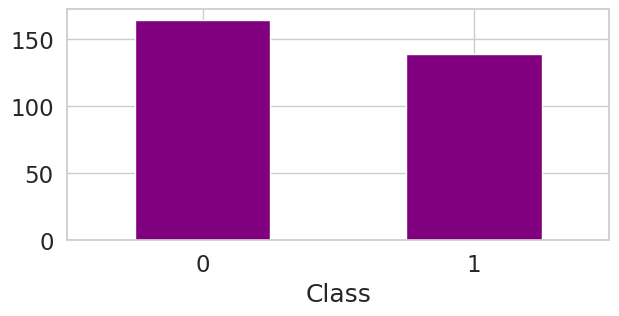

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(7, 3))

count_classes = pd.value_counts(df['num'], sort = True)
count_classes.plot(kind = 'bar', rot=0, color='purple', ax = ax)
plt.xticks(range(2), LABELS)
plt.xlabel('Class')
plt.show()

Набор плюс минус сбалансирован.
Посмотрим, как влияет холестерин и частота сердечных сокращений

In [34]:
heartDF = df[df.num == 1]   #есть вероятность заболевания
normalDF = df[df.num == 0]  #нет вероятности

In [39]:
heartDF.chol.mean()

251.4748201438849

In [38]:
normalDF.chol.mean()

242.640243902439

In [47]:
heartDF.thalach.describe()

,thalach
count,139.000000
mean,139.258993
std,22.593233
min,71.000000
25%,125.000000
50%,142.000000
75%,156.500000
max,195.000000


In [48]:
normalDF.thalach.describe()

,thalach
count,164.000000
mean,158.378049
std,19.199080
min,96.000000
25%,148.750000
50%,161.000000
75%,172.000000
max,202.000000


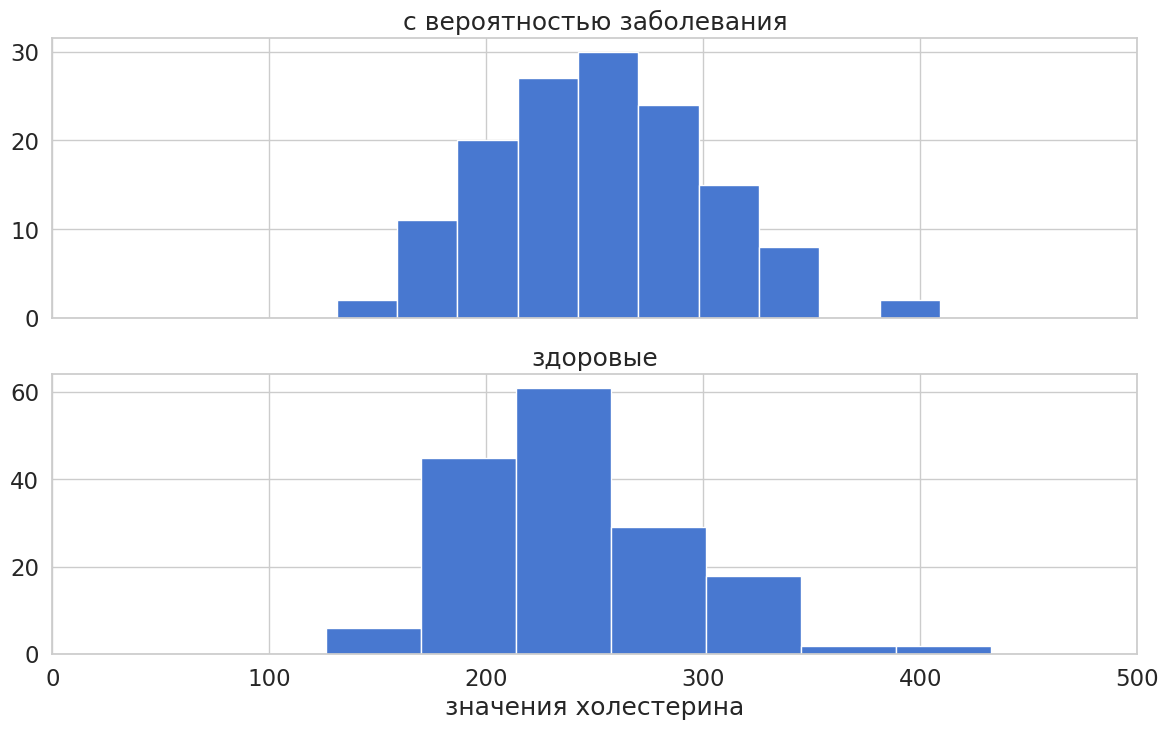

In [55]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.hist(heartDF.chol)
ax1.set_title('с вероятностью заболевания')

ax2.hist(normalDF.chol)
ax2.set_title('здоровые')

plt.xlabel('значения холестерина')
plt.xlim((0, 500))
plt.show();

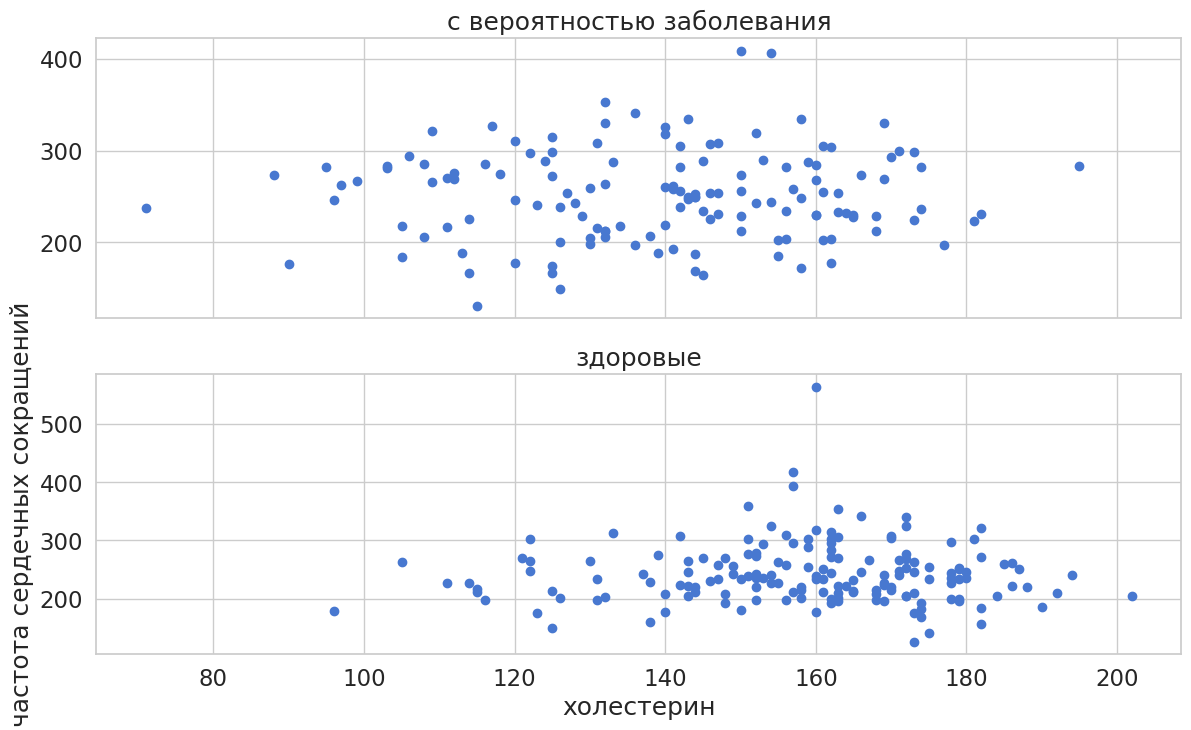

In [51]:
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

ax1.scatter(heartDF.thalach, heartDF.chol)
ax1.set_title('с вероятностью заболевания')

ax2.scatter(normalDF.thalach, normalDF.chol)
ax2.set_title('здоровые')

plt.xlabel('холестерин')
plt.ylabel('частота сердечных сокращений')
plt.show()

## Preprocessing

стандартизация данных

In [56]:
#df['chol'] = StandardScaler().fit_transform(df['chol'].values.reshape(-1, 1))

In [163]:
cols = df.columns
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']

In [166]:
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,0.936181,0.691095,-2.240629,0.750380,-0.276443,2.430427,1.010199,0.017494,-0.696419,1.068965,2.264145,-0.721976,0.655877,0
1,1.378929,0.691095,0.873880,1.596266,0.744555,-0.411450,1.010199,-1.816334,1.435916,0.381773,0.643781,2.478425,-0.894220,1
2,1.378929,0.691095,0.873880,-0.659431,-0.353500,-0.411450,1.010199,-0.899420,1.435916,1.326662,0.643781,1.411625,1.172577,1
3,-1.941680,0.691095,-0.164289,-0.095506,0.051047,-0.411450,-1.003419,1.633010,-0.696419,2.099753,2.264145,-0.721976,-0.894220,0
4,-1.498933,-1.446980,-1.202459,-0.095506,-0.835103,-0.411450,1.010199,0.978071,-0.696419,0.295874,-0.976583,-0.721976,-0.894220,0


### Разделите набор данных на наборы обучающих и тестовых данных.

 набор данных как обучение = 80% и тест = 20%
 в обучающем наборе данных будут только здоровые, а в тестовом наборе данных будут все

In [167]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42)
X_train = X_train[X_train['num'] == 0]
X_train = X_train.drop(['num'], axis=1)

y_test = X_test['num']
X_test = X_test.drop(['num'], axis=1)

X_train = X_train.values

X_test = X_test.values
y_test = y_test.values
print(y_test.size)

60


## Model

автоэнкодер, состоящий из 4 полносвязных слоев с 13, 8, 4, 13 нейронами.
Первые 2 слоя действуют как кодировщик, а последние 2 слоя действуют как декодер

последний слой имеет 13 узлов, соответствующих 13 функциям в элементе входных данных.

In [170]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        #кодирующий слой
        self.encoder = nn.Sequential(
            nn.Linear(13, 8),
            nn.Tanh(),
            nn.Linear(8, 4),
            nn.LeakyReLU(),
            )

        #декодирующий
        self.decoder = nn.Sequential(
           nn.Linear(4, 8),
           nn.Tanh(),
           nn.Linear(8, 13),
           nn.LeakyReLU()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [171]:
model = Autoencoder().double()

In [172]:
num_epochs = 100   # сколько эпох будем обучать. Результаты обучения на одной эпохе используются как начальные для следующей.
minibatch_size = 32
learning_rate = 1e-3

**minibatch_size** - размер мини-пакета - это количество записей/векторов, которые передаются в наш алгоритм обучения.

Отношение между тем, насколько быстро наш алгоритм может обучить модель, обычно имеет U-образную форму (размер пакета в зависимости от скорости обучения). Это означает, что первоначально по мере увеличения размера партии время обучения будет уменьшаться. В конце концов мы увидим, что время обучения начинает увеличиваться, когда мы превышаем определенный размер пакета, который слишком велик. По мере увеличения размера мини-пакета большее количество вычислений означает, что градиенты могут быть более плавными, но их вычисление требует больших затрат. В идеале каждая мини-партия, на которой проводится обучение, должна содержать пример каждого класса, чтобы уменьшить ошибку выборки при оценке градиента для всей обучающей выборки.

**learning_rate** - скорость оптимизации (обучения). Насколько маленькими шашами мы изменяем градиент.

In [173]:
train_loader = data_utils.DataLoader(X_train, batch_size=minibatch_size, shuffle=True)

In [174]:
#test = data_utils.TensorDataset(torch.from_numpy(X_test).double(),torch.from_numpy(y_test).double())
#test_loader = data_utils.DataLoader(test, batch_size=minibatch_size, shuffle=True)
test_loader = data_utils.DataLoader(X_test, batch_size=1, shuffle=False)

In [175]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
model.parameters(), lr=learning_rate, weight_decay=10e-05)

In [176]:
history = {}
history['train_loss'] = []
history['test_loss'] = []

- Проходит определенное количество эпох.
- На каждой эпохе проходит через весь обучающий набор данных с расчетом потерь.
- Производится обновление параметров модели с использованием методов обратного распространения.
- В конце сохраняются веса обученной модели для дальнейшего использования.

In [177]:
if np.any(np.isnan(df)) or np.any(np.isinf(df)):
    print("Данные содержат nan или inf значения.")

In [178]:
for epoch in range(num_epochs):
    h = np.array([])
    for data in train_loader:
        #print(type(data))
        #data = Variable(data).cpu()
        #print(type(data))
        # ===================forward=====================
        output = model(data)
        loss = criterion(output, data)
        h = np.append(h, loss.item())

        # ===================backward====================
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # ===================log========================
    mean_loss = np.mean(h)
    print('epoch [{}/{}], loss:{:.4f}'
          .format(epoch + 1, num_epochs, mean_loss))
    history['train_loss'].append(mean_loss)


torch.save(model.state_dict(), './credit_card_model.pth')

epoch [1/100], loss:1.0190
epoch [2/100], loss:1.0077
epoch [3/100], loss:1.0002
epoch [4/100], loss:0.9925
epoch [5/100], loss:0.9868
epoch [6/100], loss:0.9804
epoch [7/100], loss:0.9736
epoch [8/100], loss:0.9701
epoch [9/100], loss:0.9660
epoch [10/100], loss:0.9605
epoch [11/100], loss:0.9531
epoch [12/100], loss:0.9466
epoch [13/100], loss:0.9501
epoch [14/100], loss:0.9420
epoch [15/100], loss:0.9408
epoch [16/100], loss:0.9353
epoch [17/100], loss:0.9296
epoch [18/100], loss:0.9257
epoch [19/100], loss:0.9224
epoch [20/100], loss:0.9206
epoch [21/100], loss:0.9148
epoch [22/100], loss:0.9133
epoch [23/100], loss:0.9131
epoch [24/100], loss:0.9123
epoch [25/100], loss:0.9062
epoch [26/100], loss:0.9029
epoch [27/100], loss:0.9011
epoch [28/100], loss:0.9007
epoch [29/100], loss:0.8952
epoch [30/100], loss:0.8942
epoch [31/100], loss:0.8934
epoch [32/100], loss:0.8858
epoch [33/100], loss:0.8904
epoch [34/100], loss:0.8800
epoch [35/100], loss:0.8780
epoch [36/100], loss:0.8770
e

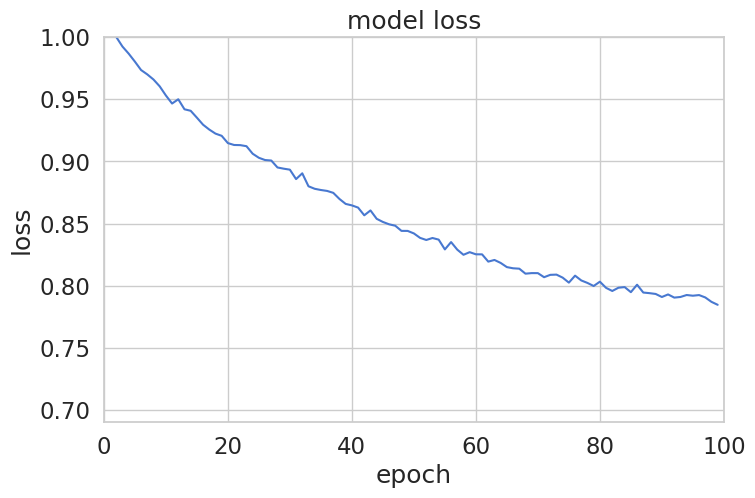

In [182]:
#history['train_loss']
#plt.plot(range(num_epochs),history['train_loss'],'ro',linewidth=2.0)

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.axis([0, 100, 0.69, 1])
#plt.legend(['train', 'test'], loc='upper right');
plt.show()

## Оценка модели

In [184]:
pred_losses = {'pred_loss' : []}
model.eval()
with torch.no_grad():
   # test_loss = 0
    for data in test_loader:
        inputs = data

        outputs = model(inputs)
        loss = criterion(outputs, inputs).data.item()

        pred_losses['pred_loss'].append(loss)

reconstructionErrorDF = pd.DataFrame(pred_losses)
reconstructionErrorDF['num'] = y_test

In [185]:
reconstructionErrorDF.describe()

,pred_loss,num
count,60.000000,60.000000
mean,0.870526,0.400000
std,0.447094,0.494032
min,0.407319,0.000000
25%,0.601752,0.000000
50%,0.783930,0.000000
75%,1.027147,1.000000
max,3.204137,1.000000


# Reconstruction Errors without Fraud

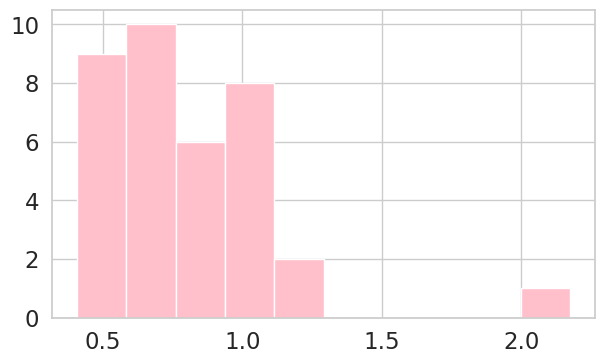

In [193]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)
normal_error_df = reconstructionErrorDF[(reconstructionErrorDF['num']== 0) & (reconstructionErrorDF['pred_loss'] < 10)]
_ = ax.hist(normal_error_df.pred_loss.values, bins=10, color = 'pink')

# Reconstruction Errors with Fraud

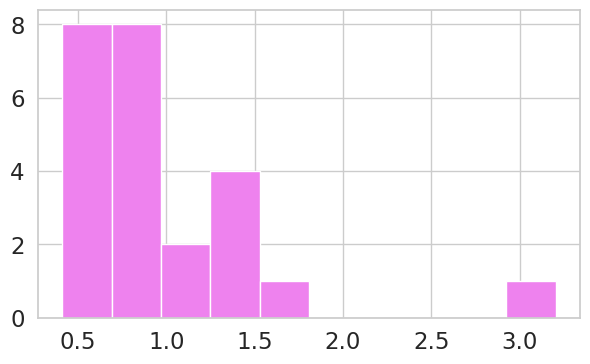

In [194]:
fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot(111)
fraud_error_df = reconstructionErrorDF[(reconstructionErrorDF['num']== 1) ]
_ = ax.hist(fraud_error_df.pred_loss.values, bins=10, color = 'violet')

## ROC Curves

ROC-кривая очень часто используется для анализа бинарных классификаторов. Он рассматривает все возможные пороговые значения для данного классификатора и показывает процент ложных срабатываний (FPR) по сравнению с показателями истинно положительных результатов (TPR).

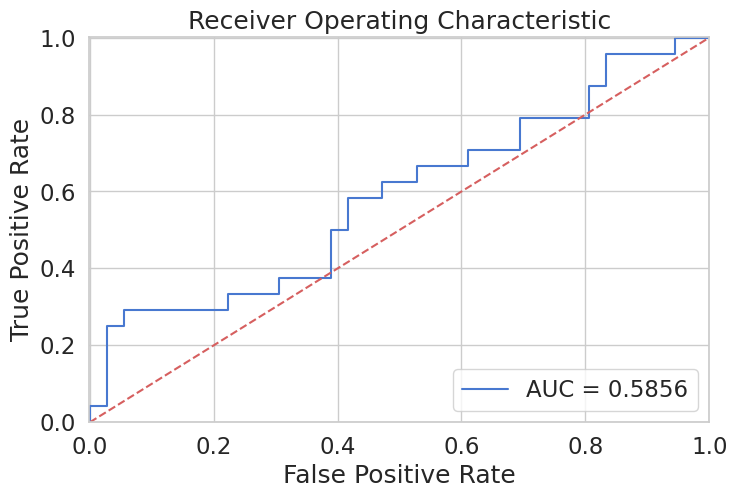

In [197]:
fpr, tpr, thresholds = roc_curve(reconstructionErrorDF.num, reconstructionErrorDF.pred_loss)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 5))
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, label='AUC = %0.4f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.001, 1])
plt.ylim([0, 1.001])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show();

## Precision vs Recall

Установка порога, который используется для принятия решения о классификации в модели, — это способ настроить компромисс между точностью (precision) и полнотой (recall) для данного классификатора.

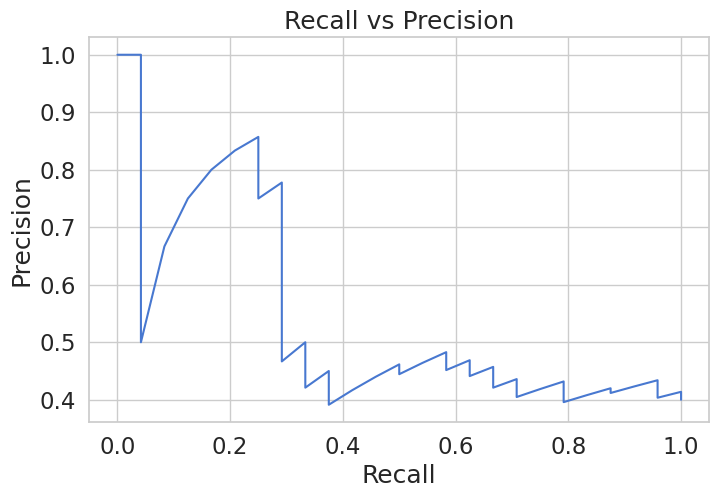

In [199]:
plt.figure(figsize=(8, 5))
precision, recall, th = precision_recall_curve(reconstructionErrorDF.num, reconstructionErrorDF.pred_loss)
plt.plot(recall, precision, 'b', label='Precision-Recall curve')
plt.title('Recall vs Precision')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

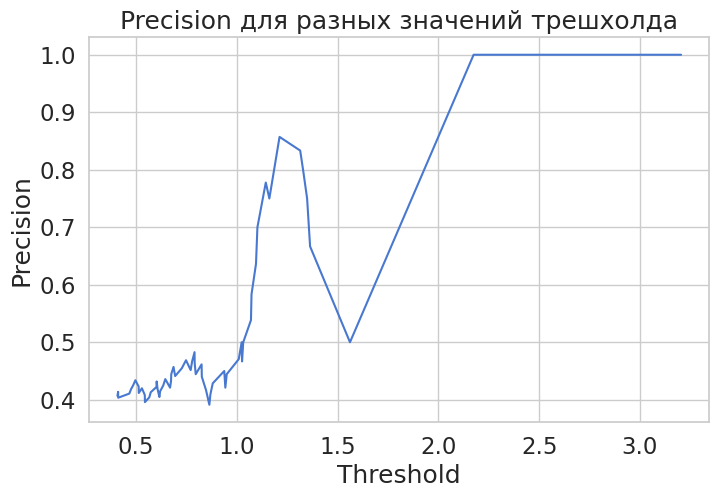

In [200]:
plt.figure(figsize=(8, 5))
plt.plot(th, precision[1:], 'b', label='Threshold-Precision curve')
plt.title('Precision для разных значений трешхолда')
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.show()

Вы можете видеть, что по мере увеличения ошибки реконструкции повышается и наша precision. Давайте посмотрим на recall:


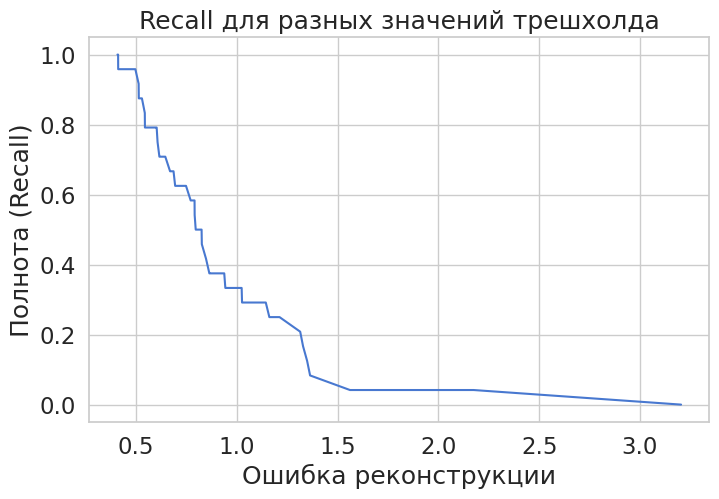

In [201]:
plt.figure(figsize=(8, 5))
plt.plot(th, recall[1:], 'b', label='Threshold-Recall curve')
plt.title('Recall для разных значений трешхолда')
plt.xlabel('Ошибка реконструкции')
plt.ylabel('Полнота (Recall)')
plt.show()

Здесь мы имеем прямо противоположную ситуацию. По мере увеличения ошибки реконструкции recall (полнота) уменьшается.

## Используем модель для того, чтобы сделать предсказание

Для предсказания вероятности заболевания у человека, рассчитаем ошибку реконструкции на основе данных.

Если ошибка превышает предопределенный порог, мы помечаем ее как есть вероятность заболевания (т.к. модель должна иметь низкую оценку при отсутствии заболевания)

In [211]:
threshold = 0.5

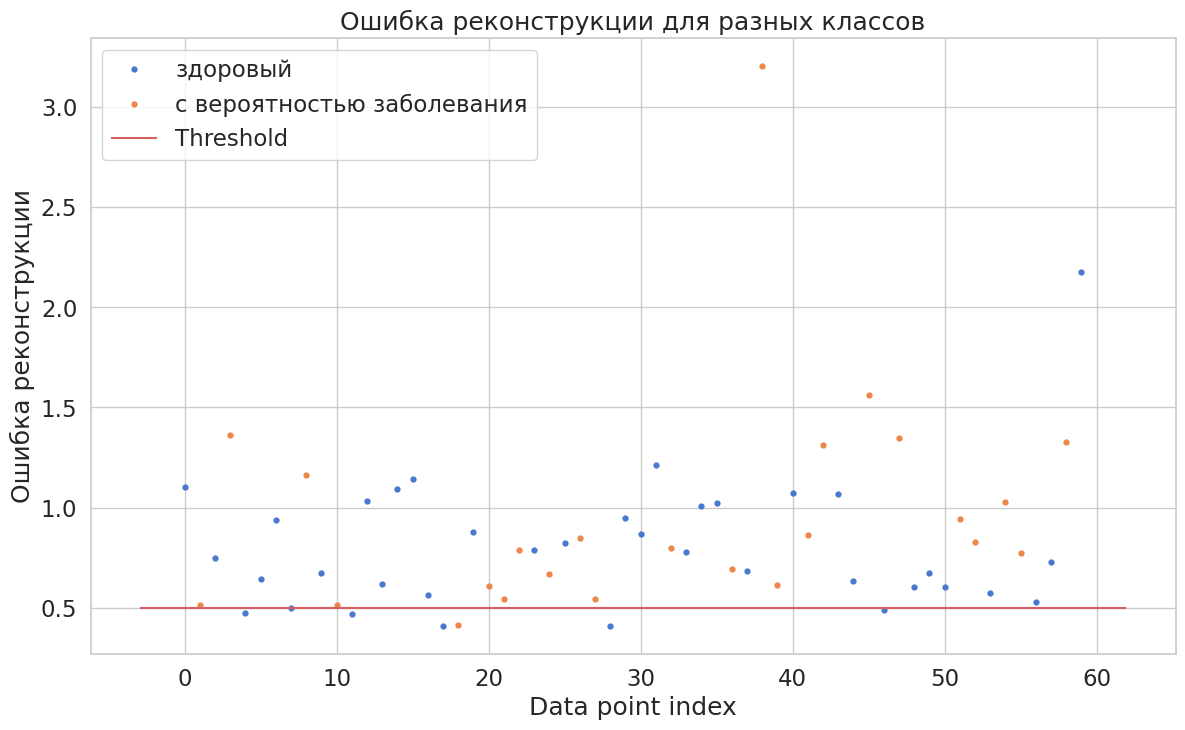

In [212]:
groups = reconstructionErrorDF.groupby('num')
fig, ax = plt.subplots()

for name, group in groups:
    ax.plot(group.index, group.pred_loss, marker='o', ms=3.5, linestyle='',
            label= "с вероятностью заболевания" if name == 1 else "здоровый")
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()

plt.title("Ошибка реконструкции для разных классов")
plt.ylabel("Ошибка реконструкции")
plt.xlabel("Data point index")
plt.show();

<ipython-input-219-8f451ae319b2>:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=plt.cm.get_cmap('Pastel1'));


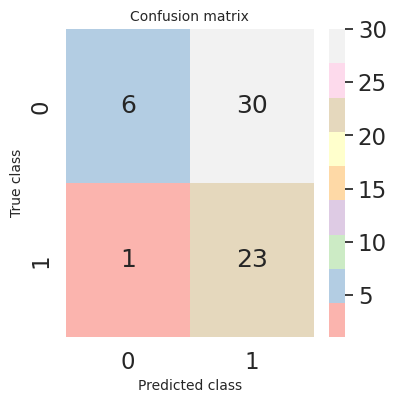

In [219]:
y_pred = [1 if e > threshold else 0 for e in reconstructionErrorDF.pred_loss.values]
conf_matrix = confusion_matrix(reconstructionErrorDF.num, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d",
            cmap=plt.cm.get_cmap('Pastel1'));
plt.title("Confusion matrix", size = 10)
plt.ylabel('True class', size = 10)
plt.xlabel('Predicted class', size = 10)
plt.show()